Treinando modelo no perfil de vibração normal...


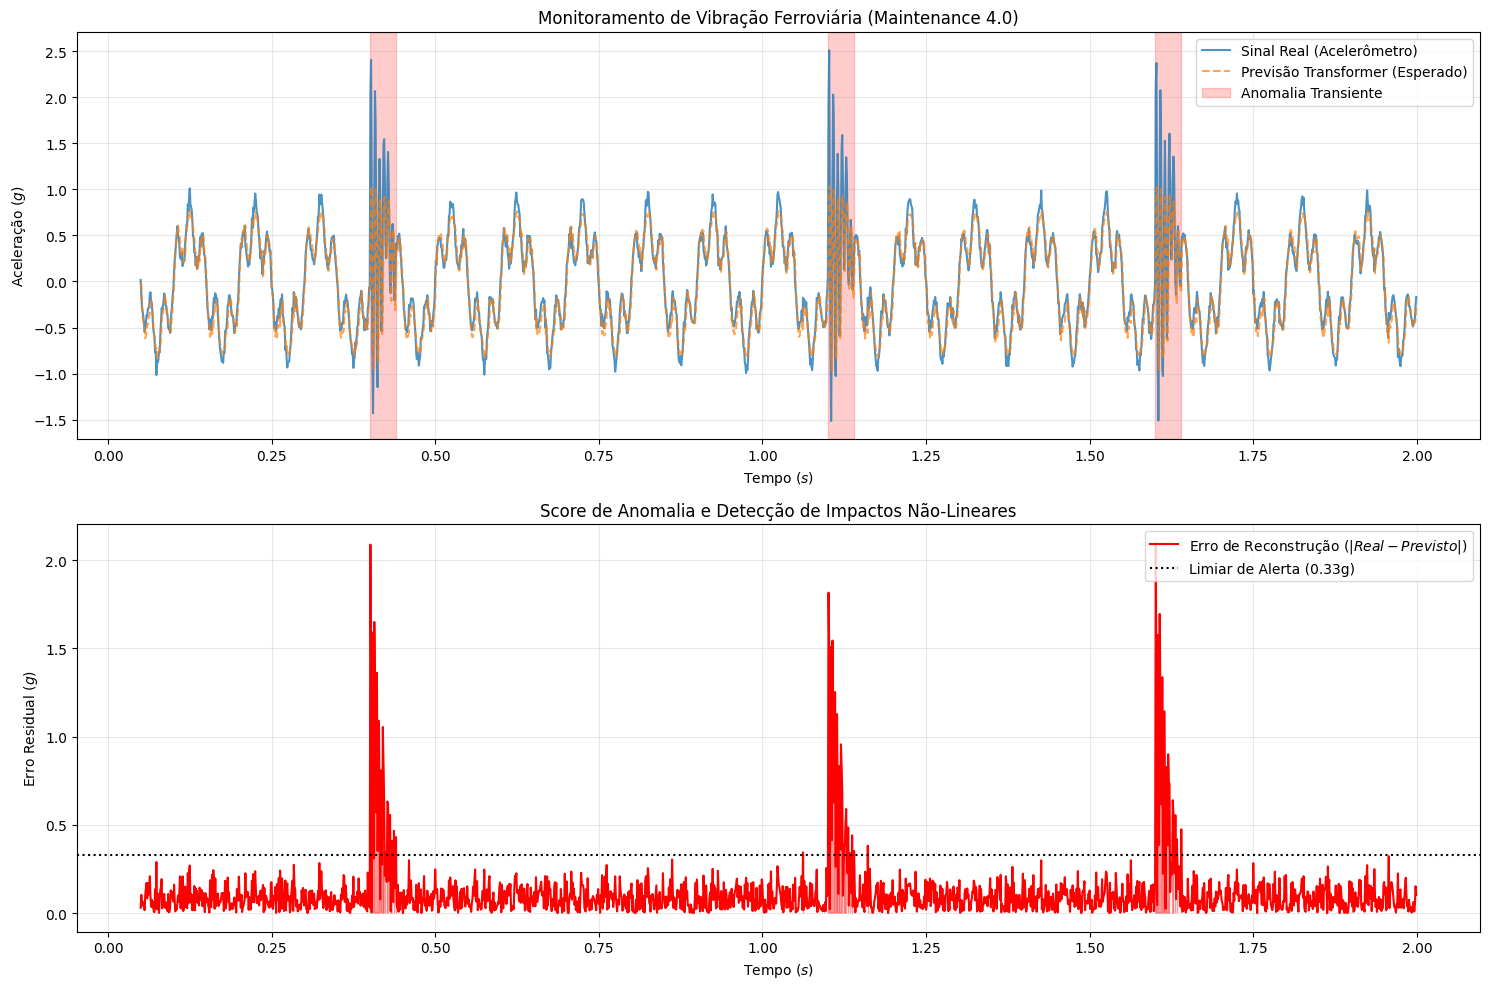

In [13]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import random

# --- 1. CONFIGURAÇÕES E GERAÇÃO DE SINAL (FISICAMENTE MOTIVADO) ---
np.random.seed(42)
torch.manual_seed(42)

def generate_rail_signal(n_points=2000, fs=1000):
    """
    Simula vibração ferroviária.
    fs: Frequência de amostragem em Hz
    """
    t = np.arange(n_points) / fs  # Tempo em segundos

    # 1. SINAL NORMAL: Estacionário e Cíclico (Harmónicas de rotação)
    # f1 = 10Hz (rotação da roda), f2 = 50Hz (vibração do truque/bogie)
    normal_signal = 0.6 * np.sin(2 * np.pi * 10 * t) + \
                    0.3 * np.sin(2 * np.pi * 50 * t) + \
                    np.random.normal(0, 0.05, n_points) # Ruído de medição

    # 2. SINAL ANÓMALO: Transiente e Não-Linear (Impactos de falha)
    anomalous_signal = normal_signal.copy()

    # Inserir anomalias em 3 momentos aleatórios
    anomaly_indices = [400, 1100, 1600]
    for start in anomaly_indices:
        duration = 40 # ms
        t_anomaly = t[start:start+duration]
        # Impacto: Decaimento exponencial de alta frequência (Ex: 150Hz)
        impact = 2.5 * np.exp(-50 * (t_anomaly - t_anomaly[0])) * \
                 np.sin(2 * np.pi * 150 * t_anomaly)
        anomalous_signal[start:start+duration] += impact

    return t, normal_signal.astype(np.float32), anomalous_signal.astype(np.float32), anomaly_indices

def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i:(i + seq_length)])
        ys.append(data[i + seq_length])
    return torch.tensor(np.array(xs)).unsqueeze(-1), torch.tensor(np.array(ys)).unsqueeze(-1)

# --- 2. ARQUITETURA TRANSFORMER ---
class RailVibrationTransformer(nn.Module):
    def __init__(self, input_dim=1, model_dim=64, num_heads=4, num_layers=2):
        super().__init__()
        self.input_fc = nn.Linear(input_dim, model_dim)
        self.pos_encoder = nn.Parameter(torch.randn(1, 100, model_dim))
        encoder_layers = nn.TransformerEncoderLayer(d_model=model_dim, nhead=num_heads,
                                                    batch_first=True, dropout=0.1)
        self.transformer = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.output_fc = nn.Linear(model_dim, 1)

    def forward(self, x):
        x = self.input_fc(x) + self.pos_encoder[:, :x.size(1), :]
        x = self.transformer(x)
        return self.output_fc(x[:, -1, :])

# --- 3. TREINO NO PADRÃO NORMAL ---
FS = 1000 # 1kHz amostragem
SEQ_LEN = 50
t, signal_normal, signal_anomalo, anomaly_starts = generate_rail_signal(2000, FS)

# Treinamos apenas com o que é "Saudável"
X_train, y_train = create_sequences(signal_normal[:1000], SEQ_LEN)

model = RailVibrationTransformer()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

print("Treinando modelo no perfil de vibração normal...")
model.train()
for epoch in range(60):
    optimizer.zero_grad()
    pred = model(X_train)
    loss = criterion(pred, y_train)
    loss.backward()
    optimizer.step()

# --- 4. DETECÇÃO NO SINAL MISTO (INFERÊNCIA) ---
X_test, y_test = create_sequences(signal_anomalo, SEQ_LEN)
model.eval()
with torch.no_grad():
    predictions = model(X_test)
    # Cálculo do Erro de Previsão (Resíduo)
    error = torch.abs(predictions - y_test).numpy()

# --- 5. VISUALIZAÇÃO COM UNIDADES ---
plt.figure(figsize=(15, 10))

# Top Plot: Sinal de Aceleração
plt.subplot(2, 1, 1)
plt.plot(t[SEQ_LEN:], y_test.numpy(), label='Sinal Real (Acelerômetro)', color='#1f77b4', alpha=0.8)
plt.plot(t[SEQ_LEN:], predictions.numpy(), label='Previsão Transformer (Esperado)', color='#ff7f0e', linestyle='--', alpha=0.7)
for start in anomaly_starts:
    plt.axvspan(t[start], t[start+40], color='red', alpha=0.2, label='Anomalia Transiente' if start == anomaly_starts[0] else "")
plt.ylabel('Aceleração ($g$)')
plt.xlabel('Tempo ($s$)')
plt.title('Monitoramento de Vibração Ferroviária (Maintenance 4.0)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Bottom Plot: Erro de Previsão (Métrica de Falha)
plt.subplot(2, 1, 2)
plt.plot(t[SEQ_LEN:], error, color='red', label='Erro de Reconstrução ($|Real - Previsto|$)')
# Limiar estatístico: Média + 4 Desvios Padrão do sinal normal
threshold = np.mean(error[:300]) + 4 * np.std(error[:300])
plt.axhline(y=threshold, color='black', linestyle=':', label=f'Limiar de Alerta ({threshold:.2f}g)')
plt.fill_between(t[SEQ_LEN:], 0, error.flatten(), where=(error.flatten() > threshold), color='red', alpha=0.4)

plt.ylabel('Erro Residual ($g$)')
plt.xlabel('Tempo ($s$)')
plt.title('Score de Anomalia e Detecção de Impactos Não-Lineares')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()